In [1]:
import spd
import spd.utils.visualization as vsd
import spd.initial_conditions as ic
from spd.sdfb_simulator import SPD_Simulator
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams['font.size'] = 15
from functools import partial

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['1.08GB', '42.41GB']


In [3]:
def spd_sim(p,N,P0=1,**kwargs):
    return SPD_Simulator(p=p,
                  N=(N, N//4),
                  xlim=(0.0, 4.0),
                  ylim=(0.0, 1.0),
                  BC=(("doublemach", "doublemach"), ("doublemach", "doublemach")),
                  init_fct=ic.double_mach_reflection(),
                  cfl_coeff=0.4,use_cupy=True,
                  time_integrator="rk3",
                  fallback="MUSCL",
                  NAD="",
                  PAD=True,
                  SED=True,
                  blending=False,
                  riemann_solver_fv="hllc",  # MUSCL fallback flux
                  **kwargs)
    

t=0.2, steps taken 638, time taken 71.954, bzcps = 0.0


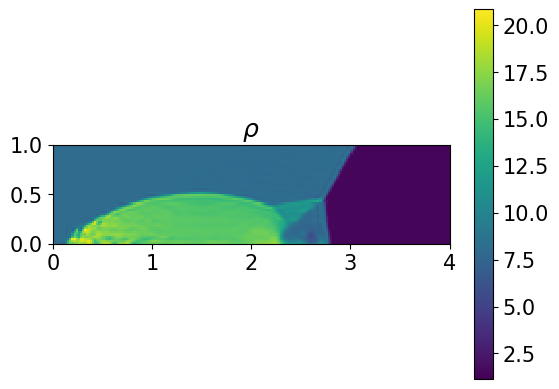

In [4]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            scheme="SDFB",
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-1,
            riemann_solver_sd="hllc")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=0.2, steps taken 612, time taken 48.675, bzcps = 0.0


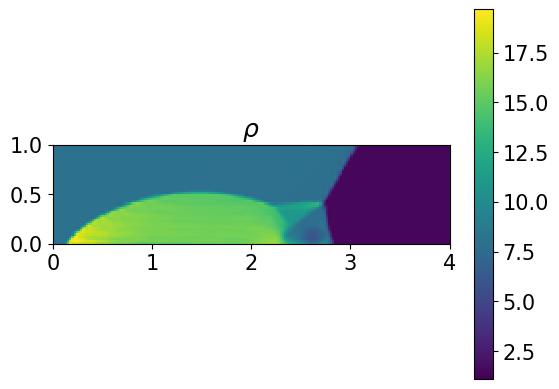

In [5]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            scheme="SDFB",
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-5,
            riemann_solver_sd="hllc")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=0.2, steps taken 612, time taken 43.829, bzcps = 0.0


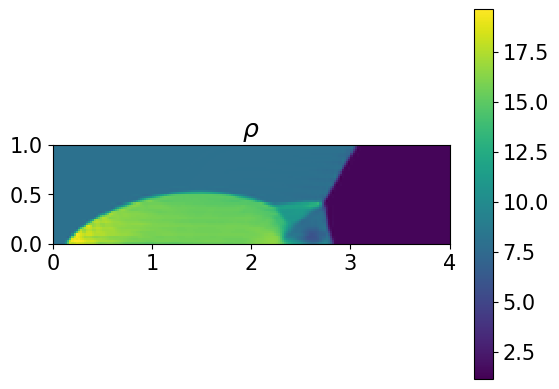

In [6]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            scheme="SDFB",
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-5,
            riemann_solver_sd="llf")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=0.2, steps taken 612, time taken 49.322, bzcps = 0.0


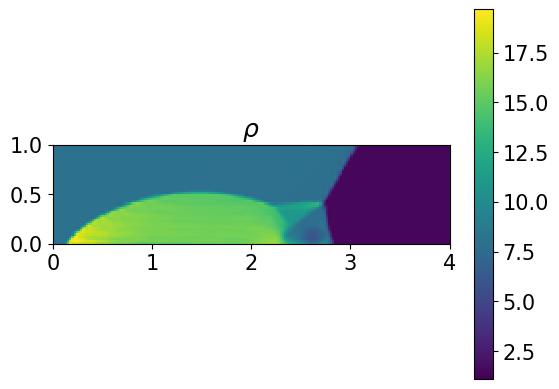

In [7]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            scheme="SDFB",
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-5,
            riemann_solver_sd="hllc")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=0.2, steps taken 614, time taken 48.661, bzcps = 0.0


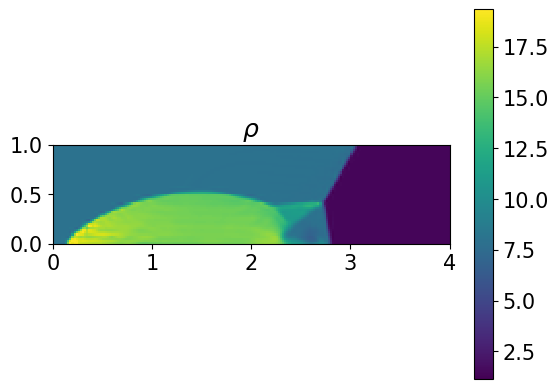

In [8]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            scheme="SDFB",
            limiting_variables=[0, 4],
            tolerance=1e-5,
            riemann_solver_sd="hllc")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=1.95, steps taken 5256, time taken 362.316, bzcps = 0.0


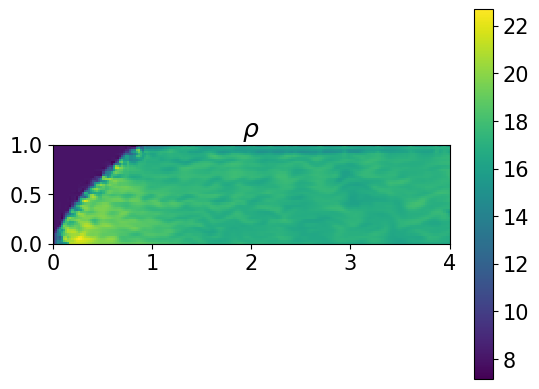

In [9]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            scheme="SDFB",
            limiting_variables=[0, 4],
            tolerance=1e-5,
            riemann_solver_sd="llf")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

t=1.95, steps taken 5121, time taken 407.477, bzcps = 0.0


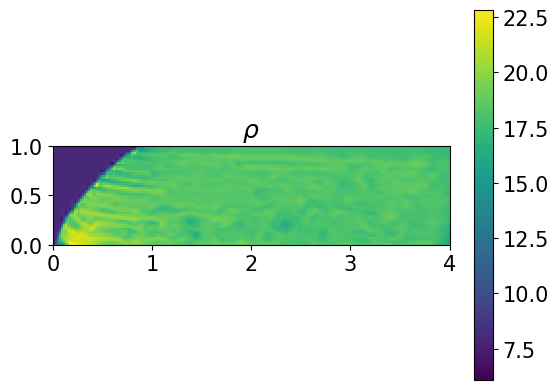

In [10]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            scheme="SDFB",
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-2,
            riemann_solver_sd="hllc")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")